# Predictive Maintenance using Machine Learning

#### Predicting Industrial Equipment Falures with Sensor Data

#### Business Problem

Unexpected machine failures can generate significant operational and financial losses in industrial environments.

Common consequences include:

- Production downtime
- Increased maintenance costs
- Reduced operational efficiency
- Safety risks
- Supply chain disruptions

Traditional maintenance offers a more efficient alternative by using operational sensor data to identify failure patterns before breakdowns happen.

The objective of this project is to develop a machine learning classification system capable of predicting machine failures using telemetry data.

From a business perspective, missed failures are typically more expensive than unnecessary inspections. For his reason, the project proritizes recall while maintaining a practical balance with precision.

#### Project Objectives

This project aims to:
- Analyze operational sensor data
- Identify operational patterns associated with machine failures
- Compare multiple classification algorithms
- Evaluate trade-offs between recall and precision
- Select the most operationally effective model for predictive maintenance scenarios
- Interpret results from technical and operational perspectives

#### Dataset Overview

The dataset contains telemetry information collected from industrial machines. 

Each observation represents the operational state of a machine using variables such as:
- Air temperature
- Process temperature
- Rotational speed
- Torque
- Tool wear
  
The target variable indicates whether a machine failure occurred.

#### Why this problem is challenging

Predictive maintenance is inherently an imbalanced classification problem. 

Failure events represent only a small fraction of the observations, meaning a model could achieve high overall accuracy while still failing to detect actual breakdowns.

In real industrial environments, this type of failure can be extremely costly because indetected issues may result in unplanned downtime, damage equipment, or production interruptions.

Because of this, the evaluation strategy focuses prinarily on:

- Recall
- F1-score
- Precision

rather than relying solely on accuracy.

### Imports

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, recall_score, precision_score, f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_validate
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

### Initial Data Exploration

Before training machine learning models, it is important to understand:
- Dataset structure
- Data quality
- Variable distributions
- Operational patterns
- Relationships between sensor variables and failures

A strong exploratory analysis helps identify potential modeling challenges before moving into training and optimization.

In [10]:
df = pd.read_csv('ai4i2020.csv')
df.set_index('UDI', inplace = True)
#df.drop(columns = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF'], inplace = True)

In [11]:
df.head()

,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
UDI,,,,,,,,,,,,,
1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [12]:
df.shape

(10000, 13)

### Target Distribution

In [14]:
df['Machine failure'].value_counts()

0    9661
1     339
Name: Machine failure, dtype: int64

In [15]:
df['Machine failure'].value_counts(normalize = True)

0    0.9661
1    0.0339
Name: Machine failure, dtype: float64

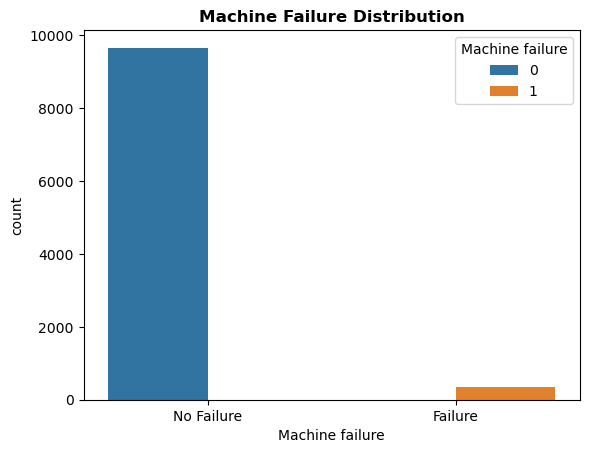

In [16]:
sns.countplot(data=df, x='Machine failure', hue='Machine failure')
plt.title('Machine Failure Distribution', fontweight='bold')
plt.xticks([0,1], ['No Failure', 'Failure']);

The dataset is highly imbalanced, with failure events representing only a small percentage of total observations.

This creates an important modeling challenge because a classifier could predict the majority class most of the time and still achieve high accuracy while providing little operational value.

As a result, recall becomes a critical evaluation metric since the primary objective is to identify as many failures as possible before breakdowns occur.

### Feature Distributions by Failure Class

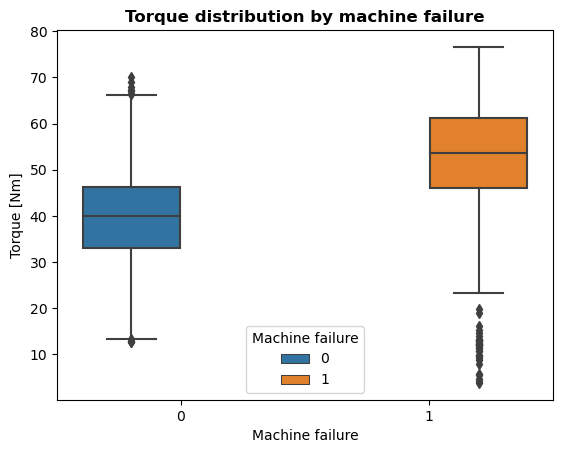

In [19]:
sns.boxplot(x = df['Machine failure'], y = df['Torque [Nm]'], hue = df['Machine failure'])
plt.title('Torque distribution by machine failure', fontweight='bold');

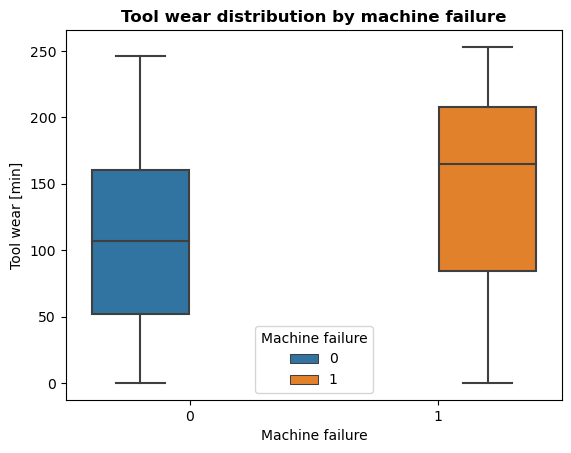

In [20]:
sns.boxplot(x = df['Machine failure'], y = df['Tool wear [min]'], hue = df['Machine failure']);
plt.title('Tool wear distribution by machine failure', fontweight='bold');

The separation between failure and non-failure distributions indicates that non-linear relationships may exist within the data.

### Correlation Analysis

In [23]:
df_corr = df.drop(columns = ['Product ID', 'Type'])
corr_matrix = df_corr.corr()

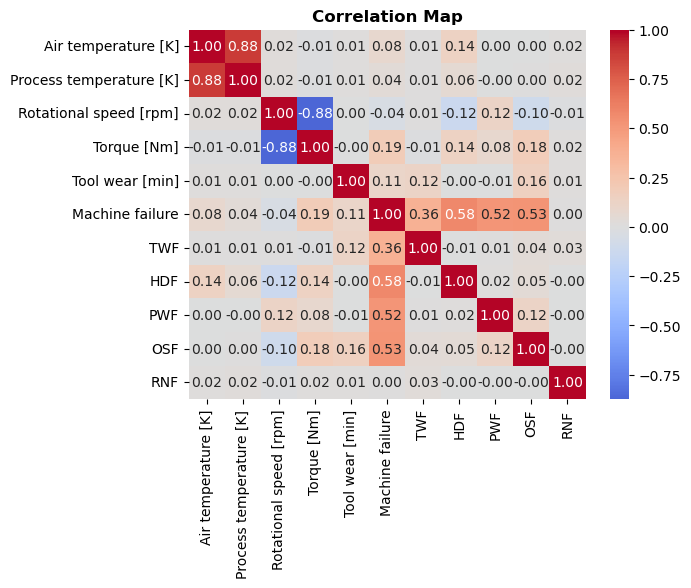

In [24]:
sns.heatmap(corr_matrix, annot = True, fmt = '.2f', cmap = 'coolwarm', center = 0)
plt.title('Correlation Map', fontweight='bold');

Several operational variables exhibit moderate correlations, which is expected in industrial systems where machine components interact under shared operating conditions.

The analysis helps identify:

- Potential redundacy between variables
- Operational dependencies
- Features with stronger predictive potential

No sever multicollinearity issues are immediately observed.

### Key findings from the Exploratory Analysis

- Failure events are relatively rare, confirming the presence of severe class imbalance.
- Torque and tool wear appear strongly associated with machine failures.
- Operational variables show meaningful operational differences between normal and failure states.
- The relationships between sensor variables suggest that non-linear models may outperform simpler linear approaches.

### Data Preprocessing

Before training machine learning models, several preprocessing steps were required to ensure data quality and model compability

### Feature Selection

In [31]:
df.drop(columns = ['Product ID', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'], inplace = True)

Certain variables were excluded to avoid data leakage and preserve realistic predictive conditions

In [33]:
X = df.drop(columns = 'Machine failure')
X = pd.get_dummies(X, columns = ['Type'], drop_first = True)
y = df['Machine failure']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state = 42)

The selected features focus exclusively on operational telemetry information available before failure occurrence.

This ensures that the model simulates a realistic predictive maintenance scenario than relying on information unavailable during real time operation.

Categorical variables were transformed into numerical representations to ensure compability with machine learning algorithms

Stratified sampling was applied to preserve the original class distribution in both training and testing datasets.

This is particularly important in imbalanced classification problems, where improper sampling could distort model evaluation.

### Feature Scalling

In [37]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

Feature scaling was applied to algorithms sensitive to feature magnitude, particularly Logistic Regression.

Tree-based models were evaluated separately since they are generally less affected by feature scaling.

### Baseline Model - Logistic Regression

Logistic Regression was used as the baseline model to establish a simple and interpretable benchmark before evaluating more complex algorithms.

As a linear model, Logistic Regression provides a useful starting point for understanding how well based relationships between operational variables and machine failure can be captured.

Advantages of Logistic Regression include:
- High interpretability
- Fast training time
- Computational efficiency
- Strong baseline performance for binary classification tasks

In [41]:
log_reg = LogisticRegression(
    class_weight = 'balanced',
    random_state = 42,
    max_iter = 1000
)

#### Logistic Regression cross validation

In [43]:
cv_results = cross_validate(
    log_reg,
    X_train_scaled,
    y_train,
    cv = 5,
    scoring = ['recall', 'precision', 'f1'],
    return_train_score = False
)

#### Logistic Regression results

In [45]:
LR_results = pd.DataFrame({
    'Model' : ['Logistic Regression'],
    'Recall': [cv_results['test_recall'].mean()],
    'Precision' : [cv_results['test_precision'].mean()],
    'F1' : [cv_results['test_f1'].mean()]
})
results = LR_results

results

,Model,Recall,Precision,F1
0,Logistic Regression,0.804781,0.137614,0.234907


Logistic Regression achieved relatively high recall performance, meaning the model was capable of detecting a large proportion of failure events.

However, this came at the cost of very low precision, generating a substantial number of false positives.

From an operational perspective, this behavior could lead to excessive maintenance inspections and unnecessary interventions, reducing maintenance efficiency despite strong failure detection capability.

The results highlight an important challenge in predictive maintenance systems: maximizing failure detection alone is not sufficient if the model produces too many false alarms.

Although the model provides strong interpretability and serves as a value baseline, its overall operational balance remained limited compared to more advanced non-linear approaches.

### Tree-Based Models

To improve predictive performance, several non-linear models were evaluated.

Tree-based algorithms are particularly efective in industrial tabular datasets because they can:

- Capture non-lineart relationships
- Automatically model feature interactions
- Handle complex operational patterns
- Improve predictive flexibility compared to linear models

### Decision Tree Classifier

In [49]:
tree = DecisionTreeClassifier(
    class_weight = 'balanced',
    random_state = 42
)

In [50]:
cv_results_tree = cross_validate(
    tree, 
    X_train,
    y_train, 
    cv = 5,
    scoring = ['recall', 'precision', 'f1'],
    return_train_score = False
)

In [51]:
DT_results = pd.DataFrame({
    'Model' : ['Decision Tree'],
    'Recall': [cv_results_tree['test_recall'].mean()],
    'Precision' : [cv_results_tree['test_precision'].mean()],
    'F1' : [cv_results_tree['test_f1'].mean()]
})
results = pd.concat([results, DT_results])

results

,Model,Recall,Precision,F1
0,Logistic Regression,0.804781,0.137614,0.234907
0,Decision Tree,0.616364,0.683869,0.647968


The Decision Tree improved the balance between precision and recall compared to Logistic Regression.

The model demonstrated stronger failure detection capability while reducing the nomber of false positives generated by the baseline approach.

However, its overall performance remained ledd stable than ensemble-based methods, suggesting limited generalization capability when compared to more robust tree-based algorithms,

Despite these limitations, the model provided valuable interpretability and helped reveal important operational decision patterns associated with machine failures.

## Random Forest Classifier

In [54]:
rf = RandomForestClassifier(
    class_weight = 'balanced',
    random_state = 42,
    n_estimators = 100
)

In [55]:
cv_results_rf = cross_validate(
    rf,
    X_train,
    y_train, 
    cv = 5,
    scoring = ['recall', 'precision', 'f1'],
    return_train_score = False
)

#### Random Forest results

In [57]:
RF_results = pd.DataFrame({
    'Model' : ['Random Forest'],
    'Recall': [cv_results_rf['test_recall'].mean()],
    'Precision' : [cv_results_rf['test_precision'].mean()],
    'F1' : [cv_results_rf['test_f1'].mean()]
})
results = pd.concat([results, RF_results])

results

,Model,Recall,Precision,F1
0,Logistic Regression,0.804781,0.137614,0.234907
0,Decision Tree,0.616364,0.683869,0.647968
0,Random Forest,0.435421,0.915836,0.588514


Random Forest produced a more conservative prediction behavior compared to previous models.

The model achieved strong precision performance, significantly reducing the number of false positives and unnecessary maintenance alerts.

However, this improvement came with lower recall, meaning a larger proportion of actual failures remained undetected.

This trade-off reflects an important operational consideration in predictive maintenance systems:
- Reducing false alarms may improve maintenance efficiency, but it can also increase the risk of missed breakdowns and unexpected downtime.
- Feature importance analysis suggests that variables related to operational stress (paricularly torque and tool wear) contributed strongly to failure prediction.

## XGBoost

XGBoost was evaluated because of its strong performance in structured/tabular datasets and its ability to model complex non-linear interactions.

In [61]:
X_train.columns = X_train.columns.astype(str)
X_test.columns = X_test.columns.astype(str)

X_train.columns = X_train.columns.str.replace('[', '', regex=False)
X_train.columns = X_train.columns.str.replace(']', '', regex=False)
X_train.columns = X_train.columns.str.replace('<', '', regex=False)

X_test.columns = X_test.columns.str.replace('[', '', regex=False)
X_test.columns = X_test.columns.str.replace(']', '', regex=False)
X_test.columns = X_test.columns.str.replace('<', '', regex=False)

In [62]:
scale_pos_weight = (
    y_train.value_counts()[0] / y_train.value_counts()[1]
)

In [63]:
xgb_model = XGBClassifier(
    random_state = 42,
    n_estimators = 100,
    max_depth = 3,
    learning_rate = 0.1,
    scale_pos_weight = scale_pos_weight,
    eval_metric = 'logloss'
)

In [64]:
cv_results_xgb = cross_validate(
    xgb_model,
    X_train,
    y_train,
    cv = 5,
    scoring = ['recall', 'precision', 'f1'],
    return_train_score = False
)

#### Baseline XGBoost results 

In [66]:
XGB_results = pd.DataFrame({
    'Model' : ['XGBoos baseline'],
    'Recall': [cv_results_xgb['test_recall'].mean()],
    'Precision' : [cv_results_xgb['test_precision'].mean()],
    'F1' : [cv_results_xgb['test_f1'].mean()]
})
results = pd.concat([results, XGB_results])

results

,Model,Recall,Precision,F1
0,Logistic Regression,0.804781,0.137614,0.234907
0,Decision Tree,0.616364,0.683869,0.647968
0,Random Forest,0.435421,0.915836,0.588514
0,XGBoos baseline,0.889091,0.328052,0.478819


Even without extensive optimization, XGBoost demonstrated strong predictive performance compared to the previous models.

The model achieved a more balanced relationships between recall and precision than Logistic Regression and Random Forest, improving failure detection capability while maintaining better control over false positives.

Feature importance analysis suggest that variables related to operational stress played a major role in predicting machine failures.

The results also indicate that machine failures are influenced by complex non-linear interactions between operational conditions, which tree-boosting methods are particularly effective at capturing.

### Recall Optimized XGBoost

Maximize failure detection capability, even at the cost of additional false positives.

This approach prioritizes identifying as many failures as possible in order to reduce the risk of unexpected breakdowns

In [70]:
xgb_model = XGBClassifier(
    random_state = 42,
    eval_metric = 'logloss',
    scale_pos_weight = scale_pos_weight
)

In [71]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1]
}

In [72]:
grid_recall = GridSearchCV(
    estimator = xgb_model,
    param_grid = param_grid,
    scoring = 'recall',
    cv = 5,
    n_jobs = -1,
    verbose = 1
)

Aunque el tunning fue optimizado para recall, se monitorearon metricas complementarias para evaluar el impacto operacional del incremento de sensibilidad

In [74]:
grid_recall.fit(X_train, y_train)

Fitting 5 folds for each of 18 candidates, totalling 90 fits


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraint...
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [3, 5, 7], 'n_estimators': [100, 200]},
             scoring='recall', verbose=1)

In [75]:
print('Best parameters:')
print(grid_recall.best_params_)
print('\n Best Recall:')
print(grid_recall.best_score_)

Best parameters:
{'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}

 Best Recall:
0.9519191919191918


#### Recall optimization results

In [77]:
best_xgb_recall = grid_recall.best_estimator_

cv_results_best_recall = cross_validate(
    best_xgb_recall,
    X_train,
    y_train,
    cv=5,
    scoring=['recall', 'precision', 'f1'],
    return_train_score=False
)

In [78]:
XGBR_results = pd.DataFrame({
    'Model' : ['XGBoost Recall'],
    'Recall': [cv_results_best_recall['test_recall'].mean()],
    'Precision' : [cv_results_best_recall['test_precision'].mean()],
    'F1' : [cv_results_best_recall['test_f1'].mean()]
})
results = pd.concat([results, XGBR_results])

results

,Model,Recall,Precision,F1
0,Logistic Regression,0.804781,0.137614,0.234907
0,Decision Tree,0.616364,0.683869,0.647968
0,Random Forest,0.435421,0.915836,0.588514
0,XGBoos baseline,0.889091,0.328052,0.478819
0,XGBoost Recall,0.951919,0.237218,0.379242


The recall-optimized XGBoost model successfully increased the proportion of detected failures.

From an operational perspective, this configuration reduces the probability of missed breakdowns, which can be particularly valuable in highly critical industrial environments where unexpected downtime carries significant costs.

However, the inprovement in recall also generated a larger number of false positives.

This means the system would likely trigger additional maintenance inspections, increasing operational workload and potentially reducing maintenance efficiency.

The results illustrate an important predictive maintenance trade-off.

Increasing failure sensitivity often comes at the expense of more false maintenance alerts.

### F1 Optimized XGBoost

Balance Recall and precision to achieve more operationally efficient predictions

Instead of maximizing failure detection alone, this approach attempts to maintain strong recall while reducing unnecessary maintenance interventions

In [82]:
xgb_model_f1 = XGBClassifier(
    random_state = 42,
    eval_metric = 'logloss',
    scale_pos_weight = scale_pos_weight
)

In [83]:
#Hyperparameters
param_grid_f1 = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1]
}

In [84]:
grid_f1 = GridSearchCV(
    estimator=xgb_model_f1,
    param_grid=param_grid_f1,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)

In [85]:
grid_f1.fit(X_train, y_train)

Fitting 5 folds for each of 18 candidates, totalling 90 fits


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraint...
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [3, 5, 7], 'n_estimators': [100, 200]},
             scoring='f1', verbose=1)

In [86]:
print('Best Parameters')
print(grid_f1.best_params_)
print('\nBest F1')
print(grid_f1.best_score_)

Best Parameters
{'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200}

Best F1
0.7332101343742919


#### Results

In [88]:
best_xgb_f1 = grid_f1.best_estimator_

cv_results_best_f1 = cross_validate(
    best_xgb_f1,
    X_train,
    y_train,
    cv=5,
    scoring=['recall', 'precision', 'f1'],
    return_train_score=False
)

In [89]:
XGBF1_results = pd.DataFrame({
    'Model' : ['XGBoost F1'],
    'Recall': [cv_results_best_f1['test_recall'].mean()],
    'Precision' : [cv_results_best_f1['test_precision'].mean()],
    'F1' : [cv_results_best_f1['test_f1'].mean()]
})
results = pd.concat([results, XGBF1_results])

results

,Model,Recall,Precision,F1
0,Logistic Regression,0.804781,0.137614,0.234907
0,Decision Tree,0.616364,0.683869,0.647968
0,Random Forest,0.435421,0.915836,0.588514
0,XGBoos baseline,0.889091,0.328052,0.478819
0,XGBoost Recall,0.951919,0.237218,0.379242
0,XGBoost F1,0.767677,0.706661,0.733210


The F1-optimized XGBoost model achieved a more balanced trade-off between failure detection capability and false positive control.

Compared to tecall-focused configuration, this model reduced unnecessary maintenance alerts while still maintaining strong predictive performance.

This balance makes the model more suitable for real-world industrial operations where maintenance resources, operational efficiency, and downtime reduction must all be considered simultaneously.

The results demonstrate that optimizing exclusively for recall may not always produce the most practical operational solution.

### Operational Trade-OFF Analysis
One of the most important aspects of this project was analyzing how different optimization strategies affected operational behavior.

Different model configurations produced substantially different outcomes:

- Recall-focused optimization prioritized maximum failure detection.
- F1-focused optimization provided a more balanced operational solution.

This analysis highlights that predictive maintenance systems should not be evaluated using a single metric alone.

Instead, model selection should align with:
- Business priorities 
- Maintenance costs
- Downtime impact
- Risk tolerance
- Operational efficiency goals

### Final Model Comparison

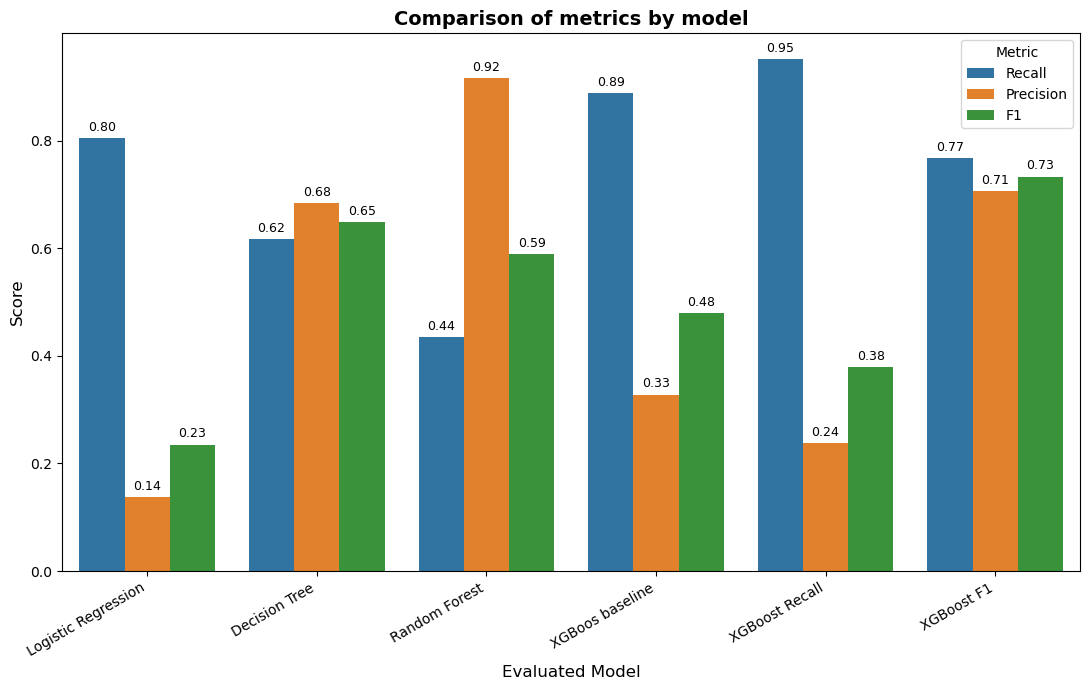

In [93]:
results_long = pd.melt(
    results, id_vars = ['Model'], value_vars = ['Recall', 'Precision', 'F1']
)
results_long.columns = ['Model', 'Metric', 'Score']

plt.figure(figsize=(11, 7))

ax = sns.barplot(data=results_long, x = 'Model', y = 'Score', hue = 'Metric')

plt.title('Comparison of metrics by model', fontsize=14, fontweight='bold')
plt.xlabel('Evaluated Model', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.xticks(rotation=30, ha='right') 

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=9, padding=3)

plt.tight_layout()
plt.show()

Although multiple models demonstrated strong predictive performance, the optimized XGBoost configurations consistently delivered the best overall operational balance.

The comparison also shows that model selection should not rely exclusively on a single evaluation metric.

In predictive maintenance environments, the optimal model depends heavily on operational priorities and the relative cost of:

- Missed failures
- Unnecessary maintenance interventions
- Production downtime
- False maintenance alerts

### Final Model Selection

The final selected model was the F1-optimized XGBoost classifier

Resons for selection
- Strong recall performance
- Better precision-recall balance
- Reduced false positive rate compared to recall-only optimization
- Stronf generalization capability
- More operationally efficient behavior

In [96]:
final_model = grid_f1.best_estimator_

In [97]:
y_pred = final_model.predict(X_test)

In [98]:
XGBtest_results = pd.DataFrame({
    'Model' : ['XGBoost Test'],
    'Recall': [recall_score(y_test, y_pred)],
    'Precision' : [precision_score(y_test, y_pred)],
    'F1' : [f1_score(y_test, y_pred)]
})
results = pd.concat([results, XGBtest_results])

results

,Model,Recall,Precision,F1
0,Logistic Regression,0.804781,0.137614,0.234907
0,Decision Tree,0.616364,0.683869,0.647968
0,Random Forest,0.435421,0.915836,0.588514
0,XGBoos baseline,0.889091,0.328052,0.478819
0,XGBoost Recall,0.951919,0.237218,0.379242
0,XGBoost F1,0.767677,0.706661,0.733210
0,XGBoost Test,0.750000,0.772727,0.761194


### Confusion Matrix

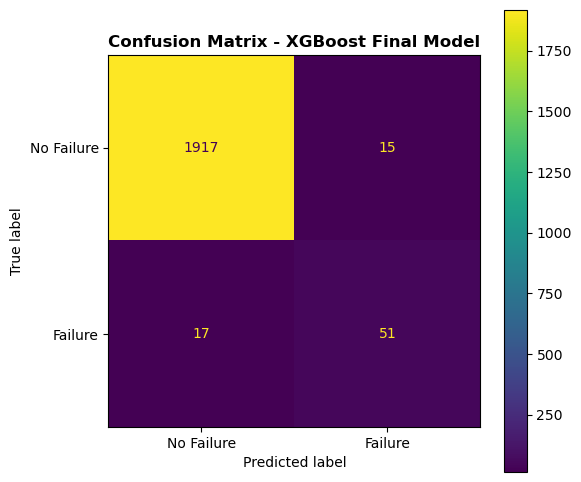

In [100]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Failure", "Failure"]
)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax)
plt.title("Confusion Matrix - XGBoost Final Model", fontweight='bold')
plt.show()

In [101]:
#Report
print('Classification Report')
print(classification_report(y_test, y_pred))

Classification Report
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.77      0.75      0.76        68

    accuracy                           0.98      2000
   macro avg       0.88      0.87      0.88      2000
weighted avg       0.98      0.98      0.98      2000



## Feature importance

In [103]:
importance = final_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X_train.columns, 
    'Importance': importance
})

In [104]:
feature_importance = feature_importance.sort_values(
    by = 'Importance',
    ascending = False
)

In [105]:
print(feature_importance)

                 Feature  Importance
2   Rotational speed rpm    0.351488
3              Torque Nm    0.260947
4          Tool wear min    0.223141
0      Air temperature K    0.055115
1  Process temperature K    0.043855
5                 Type_L    0.042336
6                 Type_M    0.023117


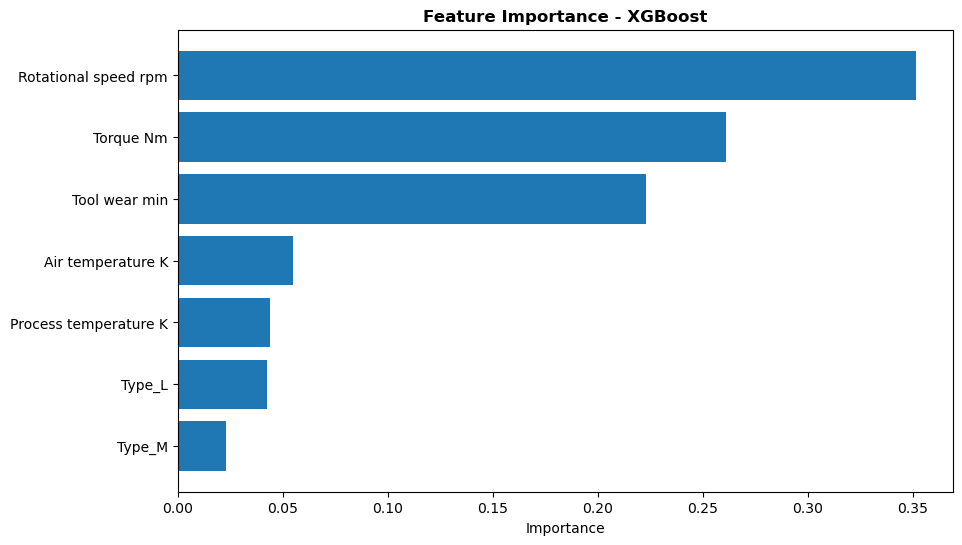

In [106]:
plt.figure(figsize = (10, 6))
plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.gca().invert_yaxis()
plt.title('Feature Importance - XGBoost', fontweight='bold')
plt.xlabel('Importance')
plt.show()

## False Negatives

In [108]:
results_df = X_test.copy()

results_df['Actual'] = y_test.values
results_df['Predicted'] = y_pred

false_negatives = results_df[
(results_df['Actual'] == 1) &
(results_df['Predicted'] ==0)
]

false_negatives.head()

,Air temperature K,Process temperature K,Rotational speed rpm,Torque Nm,Tool wear min,Type_L,Type_M,Actual,Predicted
UDI,,,,,,,,,
4852,303.7,312.1,1363,51.8,90,1,0,1,0
7885,300.8,312.4,1465,59.1,91,1,0,1,0
9175,297.8,308.9,1871,25.6,200,1,0,1,0
2672,299.7,309.3,1399,41.9,221,0,1,1,0
2865,300.6,309.4,1380,47.6,246,0,0,1,0


In [109]:
print('Count of false negatives:')
print(len(false_negatives))

Count of false negatives:
17


### Error Analysis
Additional analysis of false negatives revealed that many misclassified observations shared similar operational patterns across variables such as:

- Torque
- Rotational speed
- Tool wear

This suggests the existence of ambiguous operational regions where failure and non-failure states wxhibit highly similar sensor behavior.

As a result, achieving perfect class separation remains difficult even for advanced models such as XGBoost.

This type of analysis is particularly important in industrial machine learning applications because it helps identify operational uncertainty zones where prediction confidence may naturally decrease.                                                                   

## False positives

In [112]:
false_positives = results_df[
(results_df['Actual'] == 0) &
(results_df['Predicted'] == 1)
]

false_positives.head()

,Air temperature K,Process temperature K,Rotational speed rpm,Torque Nm,Tool wear min,Type_L,Type_M,Actual,Predicted
UDI,,,,,,,,,
4232,302.2,310.8,1340,47.8,54,1,0,0,1
8022,301.0,312.0,1499,34.6,207,0,1,0,1
1419,298.8,309.9,1320,47.4,210,1,0,0,1
5912,300.8,310.4,1288,64.0,3,0,1,0,1
5490,302.6,312.1,1499,35.0,215,1,0,0,1


In [113]:
print('Count of false positives:')
print(len(false_positives))

Count of false positives:
15


### Business Interpretation

In predictive maintenance environments:
- False negatives may lead to unexpected equipment failures and costly downtime.
- False positives may generate unnecessary inspections and maintenance costs

The selected model provides a practical balance between these competing operational risks.

Rathet than maximizing a single metric, the final solution prioritizes overall operational efficiency and decision-making precticality.

### Business Recommendations
Potential real-world applications include:

- Early failure detection systems
- Maintenance scheduling optimization
- Production downtime reduction
- Equipment monitoring dashboards
- Real-time operational risk monitoring

The model could be integrated into real-time monitoring systems where continuous sensor streams feed prediction pipelines capable of generating proactive maintenance alerts.

### Project Limitations

Although the project achieved strong predictive results, several limitations should be considered:
- The dataset represents historical observations rather than continuous time-series sensor streams
- Failure categories were simplified into a binary classification problem
- Real industrial environments may experience sensor drift and changing operational conditions over time
- Additional operational variables could further improve predictive performance

Recognizing these limitations is important when evaluating potential real-world deployment scenarios.

### Final Conclusion

This project demonstrates how machine learning can support predictive maintenance strategies using industrial telemetry sensor data.

Through exploratory analysis, preprocessing model comparison, hyperparameter optimization, and operational trade-off analysis, multiple classification approaches were evaluated to predict machine failures under imbalanced conditions.

Among the evaluated approaches, the F1-optimized XGBoost model delivered the strongest overall operational balance by combining effective failure detection capability with reduced false alarm generation.

Beyond predictive performance, this project highlights the importance of aligning machine learning evaluation metrics with business objectives, particularly in industrial environments where the operational cost of missed failures can be substantial.